Saving fashion_data_2018_2022.xls to fashion_data_2018_2022.xls
Dataset Loaded Successfully!
Index(['product_id', 'product_name', 'gender', 'category', 'pattern', 'color',
       'age_group', 'season', 'price', 'material', 'sales_count',
       'reviews_count', 'average_rating', 'out_of_stock_times', 'brand',
       'discount', 'last_stock_date', 'wish_list_count', 'month_of_sale',
       'year_of_sale'],
      dtype='object')


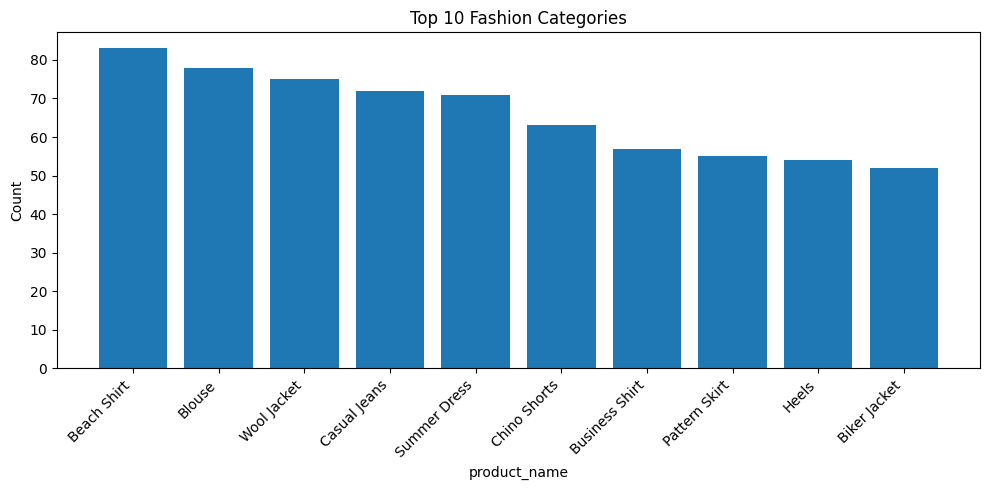

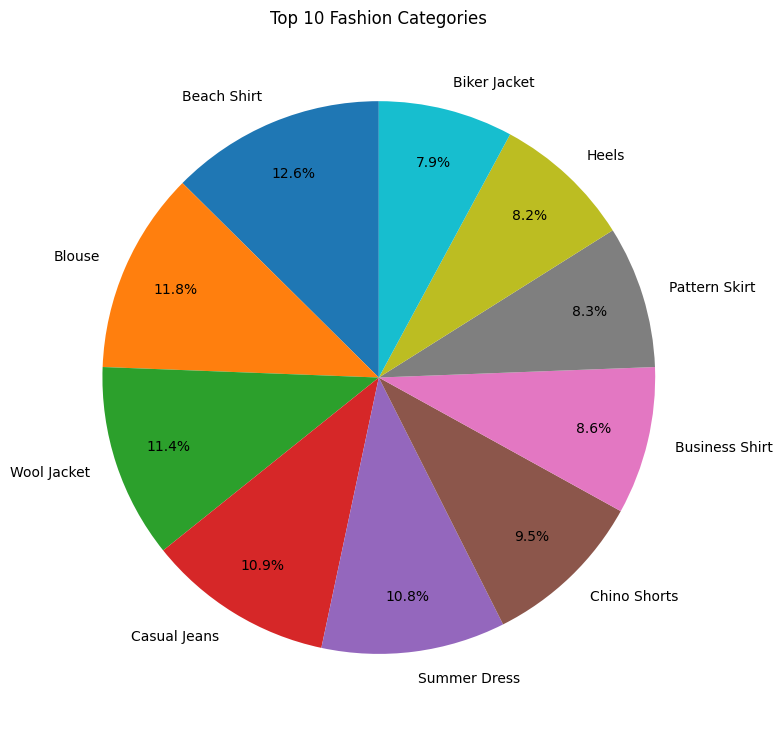

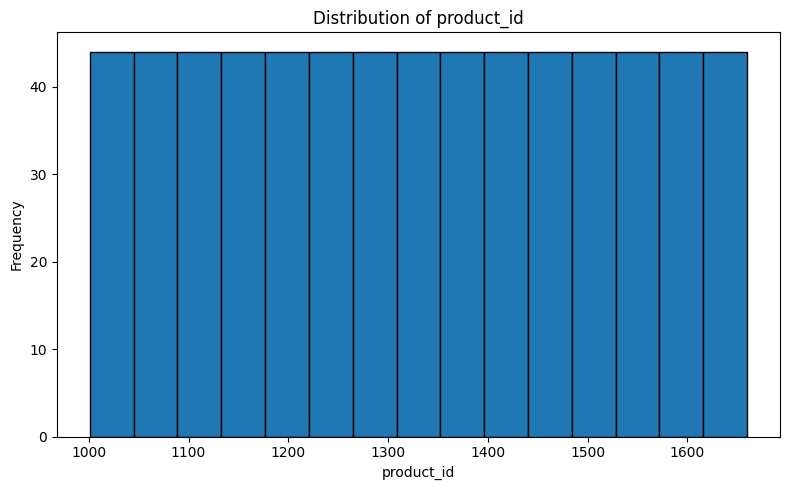

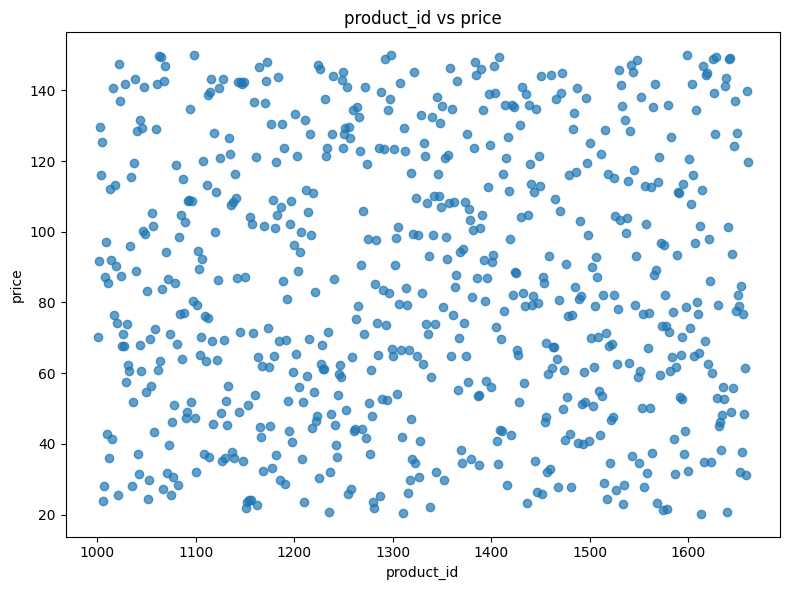

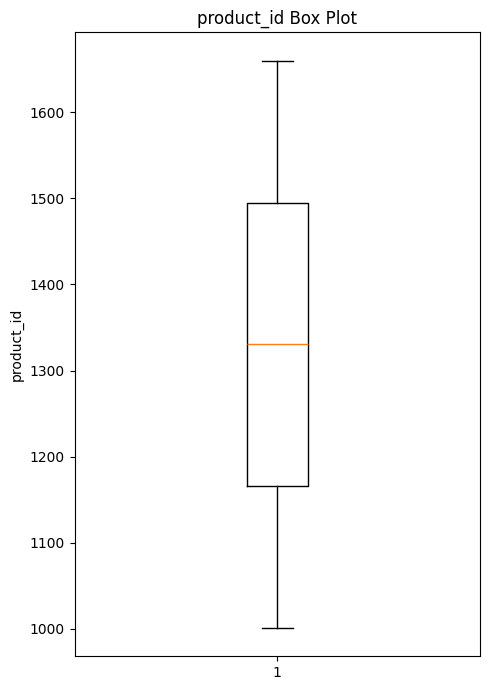

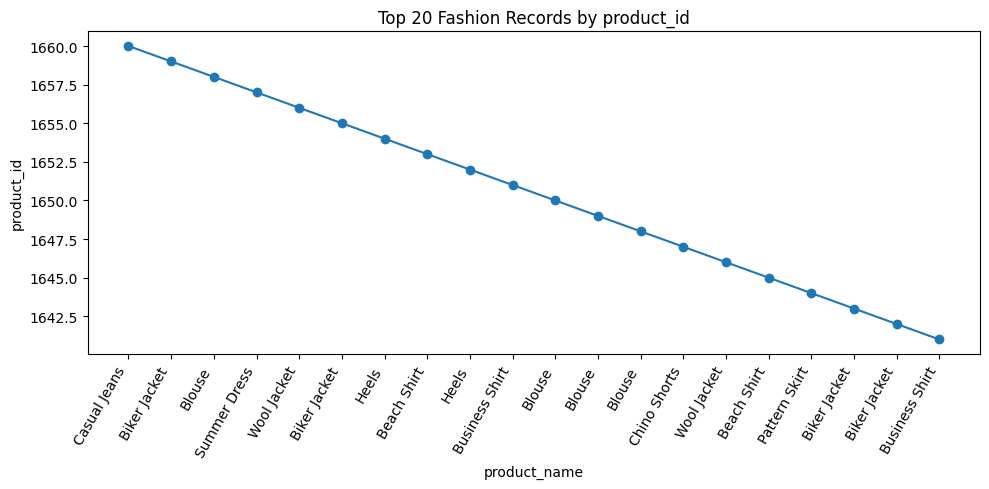

In [1]:
!pip install -q xlrd

import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

df = pd.read_excel(file_name)

print("Dataset Loaded Successfully!")
print(df.columns)

cat_cols = df.select_dtypes(include="object").columns
num_cols = df.select_dtypes(include="number").columns

category_col = cat_cols[0]
num_col1 = num_cols[0]
num_col2 = num_cols[1] if len(num_cols) > 1 else num_cols[0]

top = df[category_col].value_counts().head(10)

plt.figure(figsize=(10,5))
plt.bar(top.index, top.values)
plt.xticks(rotation=45, ha="right")
plt.xlabel(category_col)
plt.ylabel("Count")
plt.title("Top 10 Fashion Categories")
plt.tight_layout()
plt.show()

category = df[category_col].value_counts().head(10)

plt.figure(figsize=(8,8))
plt.pie(
    category.values,
    labels=category.index,
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.8,
    textprops={"fontsize":10}
)
plt.title("Top 10 Fashion Categories")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
plt.hist(df[num_col1].dropna(), bins=15, edgecolor="black")
plt.xlabel(num_col1)
plt.ylabel("Frequency")
plt.title("Distribution of " + num_col1)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,6))
plt.scatter(
    df[num_col1],
    df[num_col2],
    alpha=0.7
)
plt.xlabel(num_col1)
plt.ylabel(num_col2)
plt.title(num_col1 + " vs " + num_col2)
plt.tight_layout()
plt.show()

plt.figure(figsize=(5,7))
plt.boxplot(df[num_col1].dropna())
plt.title(num_col1 + " Box Plot")
plt.ylabel(num_col1)
plt.tight_layout()
plt.show()

top = df.nlargest(20, num_col1)

plt.figure(figsize=(10,5))
plt.plot(
    range(len(top)),
    top[num_col1],
    marker="o"
)
plt.xticks(
    range(len(top)),
    top[category_col].astype(str),
    rotation=60,
    ha="right"
)
plt.xlabel(category_col)
plt.ylabel(num_col1)
plt.title("Top 20 Fashion Records by " + num_col1)
plt.tight_layout()
plt.show()